# Customer Segmentation Analysis

This notebook performs end-to-end customer segmentation using K-Means clustering on Blinkit order data.

## Table of Contents

1. **Proposal** - Project Statement, Business Goal, Data Source, Tools and Technology, Project Workflow, Data Extraction, Schema / Data Dictionary
2. **Data Loading** - Import and load the dataset
3. **Data Validation** - Explore structure, check for nulls and anomalies
4. **Data Cleaning** - Handle missing values, remove irrelevant columns
5. **Exploratory Data Analysis** - Statistical summaries and visualizations
6. **Feature Engineering** - Aggregate customer-level features and scale
7. **Cluster Modeling** - K-Means with silhouette analysis
8. **Results & Insights** - Cluster profiles and business recommendations


## Proposal

1. **Project Statement**  
  Across customer-centric businesses, one of the major goals for the organization is being able to predict the needs of its customers and how to best cater to their needs while maintaining high profitability. However, to make the solution feasible, the way forward would be to create groups of consumers that share similar spending patterns, allowing the businesses to create targeted marketing campaigns, improve customer satisfaction, demand-oriented product development, and therefore improve *profitability*.  
     
2. **Business Goal**  
   The objective of this project is to develop a machine learning model that can create suitable and usable clusters/segments given the profile and purchases of the customer. The model should then be able to predict, within bounds of acceptable error, which segment a customer is likely to belong to. The model should allow stakeholders to make informed and data-backed decisions on product demand, campaign successes and customer retention.  
     
3. **Data Source**     
  We will use the "Blinkit Sales Dataset" for this project. This dataset provides detailed information on product sales, visibility, item types, and outlet performance, making it ideal for performing sales data analysis and gaining insights into business trends. The dataset is well-structured and suitable for data preprocessing, exploratory data analysis, and predictive modeling tasks.  
   - **Source Platform:** **Kaggle**
   - **Dataset**: Blinkit Sales Data [@blinkit_2025]  

4. **Tools and Technology**  
  Following languages and libraries are planned to be used for this project. More libraries may be used and every non trivial library shall be updated.  
    - Python  
      - Core Libraries  
        - Data Manipulation: Pandas, NumPy  
        - ML: scikit-learn  
        - Data Visualization & Storytelling: Matplotlib, Seaborn  
      - Development Environment: VS Code, Google Colab, GitHub  
    - Dashboard: Power BI   

5. **Project Workflow**  
  The project is to follow a standard data science development lifecycle,  
   1. Data Acquisition: Fetch the dataset from **Kaggle** using its API.  
   2. Preprocessing: Handle missing values (if any), encode categorical variables, and  
       check for data inconsistencies.  
   3. EDA: Analyze features to understand their relationship with attrition using statistical summaries and visualizations.  
   4. Feature Engineering: Create new features from existing ones if necessary to improve model performance.  
   5. Modeling: Train several clustering models (e.g., K Means Clustering, PCA, Decision Trees).  
   6. Evaluation: Assess model performance using metrics like Accuracy, Precision, Recall, and F1-Score. Select the best-performing model.  
   7. Visualization: Create an interactive dashboard in Power BI to present the key findings and predictions to stakeholders.  

6. **Data Extraction**   
  The "*Blinkit Sales Dataset*"  is acquired directly from the Kaggle repository. To ensure a professional and reproducible workflow, manually downloading the files is not done.  
  Instead, we will perform the following steps:  
   - Automate the Process: We will write a Python script that utilizes the official Kaggle API to connect to the source and download the dataset.  
   - Ensure Reproducibility: This scripted approach guarantees that the data extraction process is consistent and can be easily re-run by any team member or reviewer.  
   - Prepare for Analysis: The script will handle the unzipping of the downloaded files and load the data directly into a Pandas DataFrame, making it immediately available for the next phase of our project.  
   - Notebook: [Analysis Notebook](notebooks/presentation.ipynb)
     
7. **Schema / Data Dictionary**   
  This data dictionary was created after inspecting the dataset.  

In [179]:
# =============================================================================
# Library Imports
# =============================================================================

# Data Manipulation
import pandas as pd
import numpy as np

# Visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Machine Learning - Preprocessing
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder

# Machine Learning - Clustering
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')

print("Libraries loaded successfully.")

---

# 1. Data Loading

Load the Blinkit orders dataset containing customer transaction information.

In [180]:
# =============================================================================
# Dataset Loading
# =============================================================================

# Define input path (adjust based on your environment)
INPUT_PATH = "../data/raw/blinkit_orders.csv"

# Load the dataset
try:
    df = pd.read_csv(INPUT_PATH)
    print(f"✓ Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")
except FileNotFoundError:
    print(f"✗ Error: File not found at {INPUT_PATH}")
    print("  Please ensure the data file exists in the correct location.")
    raise

---

# 2. Data Validation

Perform initial data quality checks:
- Dataset dimensions and data types
- Missing value analysis
- Duplicate detection
- Anomaly checks on key columns

In [181]:
def basic_exploration(df):
    """
    Perform basic exploratory analysis on the DataFrame.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame to explore
    
    Returns:
        None (prints summary statistics)
    """
    print("=" * 60)
    print("BASIC DATA EXPLORATION")
    print("=" * 60)
    
    # Dataset shape
    print(f"\n📊 Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
    
    # Display sample rows
    print("\n📋 Sample Rows (first 5):")
    display(df.head())
    
    # Data types
    print("\n📝 Column Data Types:")
    print(df.dtypes)
    
    # Missing values
    print("\n❓ Missing Values:")
    missing = df.isnull().sum()
    if missing.sum() == 0:
        print("  ✓ No missing values found")
    else:
        print(missing[missing > 0])
    
    # Unique values
    print("\n🔢 Unique Values per Column:")
    print(df.nunique())
    
    # Duplicates
    dup_count = df.duplicated().sum()
    print(f"\n🔄 Duplicate Rows: {dup_count:,}")


def summarize_df(df):
    """
    Generate detailed summary statistics for all columns.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
    """
    print("\n" + "=" * 60)
    print("DETAILED SUMMARY STATISTICS")
    print("=" * 60)
    
    # Numerical summary
    print("\n📈 Numerical Columns:")
    display(df.describe())
    
    # Categorical summary
    cat_cols = df.select_dtypes(include=['object']).columns
    if len(cat_cols) > 0:
        print("\n📊 Categorical Columns:")
        display(df[cat_cols].describe())
    
    # Anomaly check for order_total
    if 'order_total' in df.columns:
        invalid = df[df['order_total'] <= 0]
        if len(invalid) > 0:
            print(f"\n⚠️ Warning: {len(invalid)} rows with invalid order_total (≤ 0)")
            display(invalid.head())
        else:
            print("\n✓ All order_total values are valid (> 0)")

In [182]:
basic_exploration(df)
summarize_df(df)

Shape of DataFrame:
(5000, 10)
Top 5 Rows:


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741


Basic Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   order_id                5000 non-null   int64  
 1   customer_id             5000 non-null   int64  
 2   order_date              5000 non-null   object 
 3   promised_delivery_time  5000 non-null   object 
 4   actual_delivery_time    5000 non-null   object 
 5   delivery_status         5000 non-null   object 
 6   order_total             5000 non-null   float64
 7   payment_method          5000 non-null   object 
 8   delivery_partner_id     5000 non-null   int64  
 9   store_id                5000 non-null   int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 390.8+ KB
None
Count of Null Values:
order_id                  0
customer_id               0
order_date                0
promised_delivery_time    0
actual_delivery_time      0
deliver

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id
count,5.000000e+03,5.000000e+03,5000,5000,5000,5000,5000.00000,5000,5000.000000,5000.000000
unique,NaN,NaN,5000,4999,5000,3,NaN,4,NaN,NaN
top,NaN,NaN,2023-08-23 12:04:18,2024-10-13 14:06:50,2023-08-23 12:21:18,On Time,NaN,Card,NaN,NaN
freq,NaN,NaN,1,2,1,3470,NaN,1285,NaN,NaN
mean,5.029129e+09,5.009685e+07,NaN,NaN,NaN,NaN,2201.86170,NaN,50050.318200,4999.689000
std,2.863533e+09,2.919082e+07,NaN,NaN,NaN,NaN,1303.02438,NaN,28802.276922,2886.089242
min,6.046500e+04,3.181300e+04,NaN,NaN,NaN,NaN,13.25000,NaN,43.000000,1.000000
25%,2.531421e+09,2.404314e+07,NaN,NaN,NaN,NaN,1086.21500,NaN,24928.500000,2509.250000
50%,5.074378e+09,4.997808e+07,NaN,NaN,NaN,NaN,2100.69000,NaN,50262.500000,4987.000000
75%,7.488579e+09,7.621215e+07,NaN,NaN,NaN,NaN,3156.88250,NaN,74478.250000,7500.750000


,order_date,promised_delivery_time,actual_delivery_time,delivery_status,payment_method
count,5000,5000,5000,5000,5000
unique,5000,4999,5000,3,4
top,2023-08-23 12:04:18,2024-10-13 14:06:50,2023-08-23 12:21:18,On Time,Card
freq,1,2,1,3470,1285


Rows with Invalid (≤0) Order Total:


,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id


---

# 3. Data Cleaning

Clean the dataset by:
- Removing irrelevant columns
- Handling columns with high missing values
- Imputing remaining missing values
- Converting datetime columns

In [183]:
def drop_irrelevant_columns(df, irrelevant_cols):
    """
    Remove columns that are not relevant for analysis.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        irrelevant_cols (list): Column names to drop
    
    Returns:
        pd.DataFrame: DataFrame with columns removed
    """
    cols_dropped = [col for col in irrelevant_cols if col in df.columns]
    df = df.drop(columns=cols_dropped, errors='ignore')
    print(f"✓ Dropped {len(cols_dropped)} columns: {cols_dropped}")
    return df


def drop_high_missing_value_columns(df, threshold=0.5):
    """
    Remove columns with missing value ratio above threshold.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        threshold (float): Missing ratio threshold (default 0.5 = 50%)
    
    Returns:
        pd.DataFrame: DataFrame with high-missing columns removed
    """
    missing_ratio = df.isnull().mean()
    cols_to_drop = missing_ratio[missing_ratio >= threshold].index.tolist()
    
    if cols_to_drop:
        df = df.drop(columns=cols_to_drop)
        print(f"✓ Dropped {len(cols_to_drop)} columns with >{threshold*100:.0f}% missing: {cols_to_drop}")
    else:
        print(f"✓ No columns exceed {threshold*100:.0f}% missing threshold")
    
    return df


def impute_missing_values(df):
    """
    Impute missing values using median for numeric and mode for categorical.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
    
    Returns:
        pd.DataFrame: DataFrame with missing values imputed
    """
    imputed_cols = []
    
    for col in df.columns:
        if df[col].isnull().sum() > 0:
            if df[col].dtype in ['float64', 'int64']:
                df[col] = df[col].fillna(df[col].median())
            else:
                df[col] = df[col].fillna(df[col].mode().iloc[0] if not df[col].mode().empty else 'Unknown')
            imputed_cols.append(col)
    
    if imputed_cols:
        print(f"✓ Imputed missing values in: {imputed_cols}")
    else:
        print("✓ No missing values to impute")
    
    return df


def convert_datetime_columns(df, date_cols):
    """
    Convert specified columns to datetime format.
    
    Parameters:
        df (pd.DataFrame): Input DataFrame
        date_cols (list): Column names to convert
    
    Returns:
        pd.DataFrame: DataFrame with datetime columns
    """
    for col in date_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')
    print(f"✓ Converted to datetime: {[c for c in date_cols if c in df.columns]}")
    return df


def calculate_delivery_delay(df):
    """
    Calculate delivery delay in minutes from datetime columns.
    
    Parameters:
        df (pd.DataFrame): DataFrame with delivery time columns
    
    Returns:
        pd.DataFrame: DataFrame with delivery_delay_minutes column
    """
    if 'actual_delivery_time' in df.columns and 'promised_delivery_time' in df.columns:
        df['delivery_delay_minutes'] = (
            (df['actual_delivery_time'] - df['promised_delivery_time'])
            .dt.total_seconds() / 60
        ).round(2)
        print("✓ Calculated delivery_delay_minutes")
    return df


def clean_data(df):
    """
    Execute the complete data cleaning pipeline.
    
    Parameters:
        df (pd.DataFrame): Raw input DataFrame
    
    Returns:
        pd.DataFrame: Cleaned DataFrame
    """
    print("=" * 60)
    print("DATA CLEANING PIPELINE")
    print("=" * 60)
    print(f"\nInput shape: {df.shape}")
    
    # Make a copy to avoid modifying original
    df_clean = df.copy()
    
    # Step 1: Drop irrelevant columns
    irrelevant_cols = ['order_id', 'store_id']  # IDs not useful for clustering
    df_clean = drop_irrelevant_columns(df_clean, irrelevant_cols)
    
    # Step 2: Drop high-missing columns
    df_clean = drop_high_missing_value_columns(df_clean, threshold=0.5)
    
    # Step 3: Impute remaining missing values
    df_clean = impute_missing_values(df_clean)
    
    # Step 4: Convert datetime columns
    date_cols = ['order_date', 'promised_delivery_time', 'actual_delivery_time']
    df_clean = convert_datetime_columns(df_clean, date_cols)
    
    # Step 5: Calculate delivery delay
    df_clean = calculate_delivery_delay(df_clean)
    
    print(f"\nOutput shape: {df_clean.shape}")
    print("=" * 60)
    
    return df_clean

In [184]:
# List of irrelevant columns
irrelevant_cols = ['irrelevant_column']

# Columns with high missing values threshold
threshold_high_missing_values = 0.5

# Categorical-like columns to convert
categorical_like_columns = ['payment_method', 'delivery_status']

drop_irrelevant_columns(df, irrelevant_cols)
drop_high_missing_value_columns(df, threshold=threshold_high_missing_values)
impute_missing_values(df)
remove_duplicates(df)
handle_outliers(df)
convert_to_datetime(df, columns=['order_date','actual_delivery_time', 'promised_delivery_time'])
calculate_delivery_delay(df)
convert_categorical_like_columns(df, categorical_like_columns)

# Save the cleaned dataset
df_cleaned = save_cleaned_dataset(df, 'cleaned_data.csv')

Removed 0 duplicate rows
Data cleaning completed successfully!
Final Data Shape: (5000, 11)
Data Types:
order_id                           int64
customer_id                        int64
order_date                datetime64[ns]
promised_delivery_time    datetime64[ns]
actual_delivery_time      datetime64[ns]
delivery_status                 category
order_total                      float64
payment_method                  category
delivery_partner_id                int64
store_id                           int64
delivery_delay_minutes           float64
dtype: object


---

# 4. Exploratory Data Analysis

Analyze the cleaned data to understand:
- Distribution of numerical features
- Correlation between variables
- Categorical variable breakdown

In [185]:
def print_numerical_columns(df):
    """
    Display summary statistics for numerical columns.
    
    Parameters:
        df (pd.DataFrame): Cleaned DataFrame
    """
    print("=" * 60)
    print("NUMERICAL COLUMN ANALYSIS")
    print("=" * 60)
    
    num_cols = ['order_total', 'delivery_delay_minutes']
    existing = [c for c in num_cols if c in df.columns]
    
    print("\n📊 Descriptive Statistics:")
    display(df[existing].describe())
    
    print("\n📈 Spending Distribution Quantiles:")
    if 'order_total' in df.columns:
        quantiles = df['order_total'].quantile([0.25, 0.5, 0.75, 0.90, 0.95])
        for q, v in quantiles.items():
            print(f"  {q*100:.0f}th percentile: ₹{v:,.2f}")


def print_correlation(df):
    """
    Display correlation matrix for numerical columns.
    
    Parameters:
        df (pd.DataFrame): Cleaned DataFrame
    """
    print("\n🔗 Correlation Matrix:")
    num_cols = df.select_dtypes(include=['float64', 'int64']).columns
    corr_matrix = df[num_cols].corr()
    display(corr_matrix.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1))


def print_categorical_columns(df):
    """
    Display distribution for categorical columns.
    
    Parameters:
        df (pd.DataFrame): Cleaned DataFrame
    """
    print("\n" + "=" * 60)
    print("CATEGORICAL COLUMN ANALYSIS")
    print("=" * 60)
    
    cat_cols = ['payment_method', 'delivery_status']
    
    for col in cat_cols:
        if col in df.columns:
            print(f"\n📋 {col.replace('_', ' ').title()} Distribution:")
            counts = df[col].value_counts()
            for val, count in counts.items():
                pct = count / len(df) * 100
                print(f"  {val}: {count:,} ({pct:.1f}%)")

In [186]:
print_numerical_columns(df_cleaned)
print_correlation(df_cleaned)
print_categorical_columns(df_cleaned)
filter_significantly_delayed_orders(df_cleaned)
generate_customer_summary(df_cleaned)
generate_payment_method_summary(df_cleaned)
store_wise_order_total_by_delivery_status(df_cleaned)
daily_sales_patterns_df = daily_sales_patterns(df_cleaned)

Numerical Columns
Descriptive stats
       order_total  delivery_delay_minutes
count  5000.000000             5000.000000
mean   2201.674720                4.443000
std    1302.416242                8.063929
min      13.250000               -5.000000
25%    1086.215000               -1.000000
50%    2100.690000                2.000000
75%    3156.882500                8.000000
max    6262.883750               30.000000
\Distribution of Spending
      order_total
0.25    1086.2150
0.50    2100.6900
0.75    3156.8825
0.95    4452.7910
Correlation between order total and delivery delay in minutes
                        order_total  delivery_delay_minutes
order_total                1.000000               -0.002591
delivery_delay_minutes    -0.002591                1.000000

Categorical Columns
Payment Methods Distribution
payment_method
Card      1285
Cash      1257
Wallet    1244
UPI       1214
Name: count, dtype: int64
Delivery Status Distribution
delivery_status
On Time                

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,delivery_delay_minutes
23,6905293278,97259564,2024-06-16 10:23:23,2024-06-16 10:36:23,2024-06-16 11:02:23,Significantly Delayed,1404.68,Cash,53868,4187,26.0
31,9073572548,97111069,2023-05-02 23:13:42,2023-05-02 23:25:42,2023-05-02 23:47:42,Significantly Delayed,1091.89,Card,28575,6542,22.0
62,2149289255,57579640,2024-11-01 15:00:29,2024-11-01 15:20:29,2024-11-01 15:39:29,Significantly Delayed,2687.31,Cash,25251,7315,19.0
70,2122832513,55028958,2024-02-17 19:48:14,2024-02-17 19:58:14,2024-02-17 20:18:14,Significantly Delayed,2037.94,UPI,39396,5245,20.0
76,5127172657,32293017,2024-06-11 18:11:31,2024-06-11 18:30:31,2024-06-11 18:50:31,Significantly Delayed,2185.50,Cash,80034,288,20.0


493

Summary Table for Each Customer:


,total_spent,order_count,avg_delivery_delay
customer_id,,,
77869660,19052.94,9,5.666667
17805991,18409.90,8,4.625000
8791577,19028.36,8,7.750000
93018527,9521.09,7,0.142857
12832151,17178.65,7,6.000000
75213636,10038.08,7,1.142857
10562528,11050.11,7,2.714286
13604883,14002.59,7,3.000000
21701991,11648.60,7,5.571429


...

,avg_order_value,num_orders
payment_method,,
Card,2229.496449,1285
Cash,2204.028632,1257
UPI,2189.458323,1214
Wallet,2182.479317,1244


Store-Wise Order Total by Delivery Status:


delivery_status,On Time,Significantly Delayed,Slightly Delayed
store_id,,,
1,1172.69,0.00,0.00
2,22.14,0.00,0.00
9,1599.11,0.00,0.00
12,1639.04,0.00,0.00
14,0.00,704.19,0.00
...,...,...,...
9984,3327.67,0.00,0.00
9987,1052.23,0.00,0.00
9989,0.00,3706.10,0.00


Daily Sales Patterns:


,total_sales,num_orders
order_date,,
2024-11-04,13820.12,4
2024-11-03,28761.95,12
2024-11-02,10794.55,5
2024-11-01,14781.03,9
2024-10-31,25689.95,8
2024-10-30,23835.14,13
2024-10-29,11223.88,7
2024-10-28,17221.29,8
2024-10-27,11797.07,5


## 4.1 Visualizations

Visual exploration of key features and relationships.

In [187]:
def univariate_numeric_features(df):
    """
    Create distribution plots for numerical features.
    
    Parameters:
        df (pd.DataFrame): Cleaned DataFrame
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Order Total Distribution
    sns.histplot(df['order_total'], kde=True, bins=50, ax=axes[0], color='steelblue')
    axes[0].set_title('Order Total Distribution', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Order Total (₹)')
    axes[0].set_ylabel('Frequency')
    
    # Delivery Delay Distribution
    sns.histplot(df['delivery_delay_minutes'], bins=20, ax=axes[1], color='coral')
    axes[1].set_title('Delivery Delay Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Delivery Delay (minutes)')
    axes[1].set_ylabel('Frequency')
    axes[1].axvline(x=0, color='green', linestyle='--', label='On-time threshold')
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()


def univariate_categorical_features(df):
    """
    Create distribution plots for categorical features.
    
    Parameters:
        df (pd.DataFrame): Cleaned DataFrame
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Delivery Status Breakdown
    delivery_counts = df['delivery_status'].value_counts()
    axes[0].pie(delivery_counts, labels=delivery_counts.index, autopct='%1.1f%%',
                colors=sns.color_palette('Set2'), startangle=90)
    axes[0].set_title('Delivery Status Breakdown', fontsize=12, fontweight='bold')
    
    # Payment Method Distribution
    payment_counts = df['payment_method'].value_counts()
    sns.barplot(x=payment_counts.index, y=payment_counts.values, ax=axes[1],
                palette='viridis')
    axes[1].set_title('Payment Method Distribution', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Payment Method')
    axes[1].set_ylabel('Count')
    
    # Add value labels
    for i, v in enumerate(payment_counts.values):
        axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()

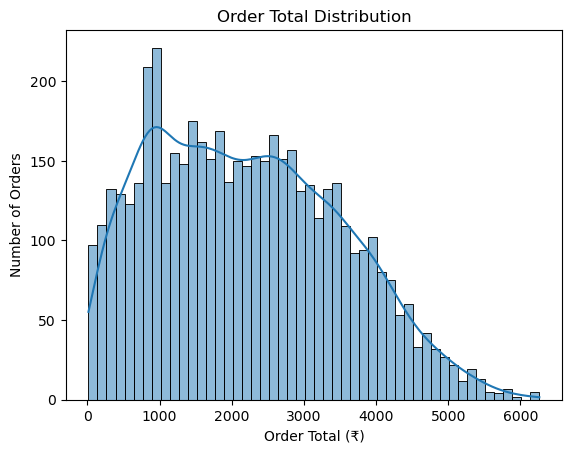

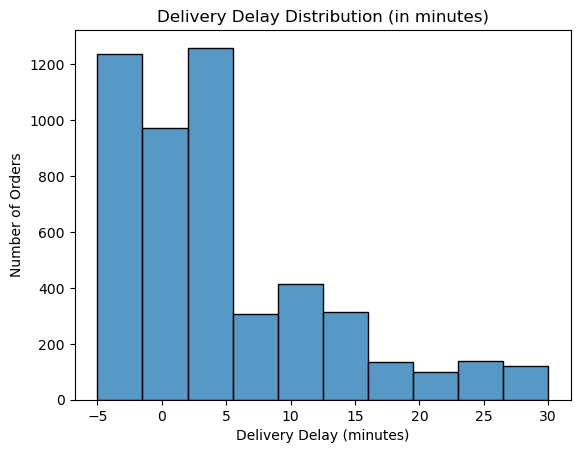

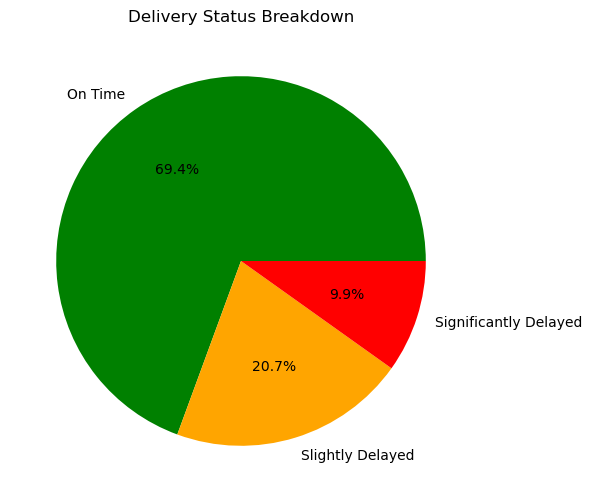

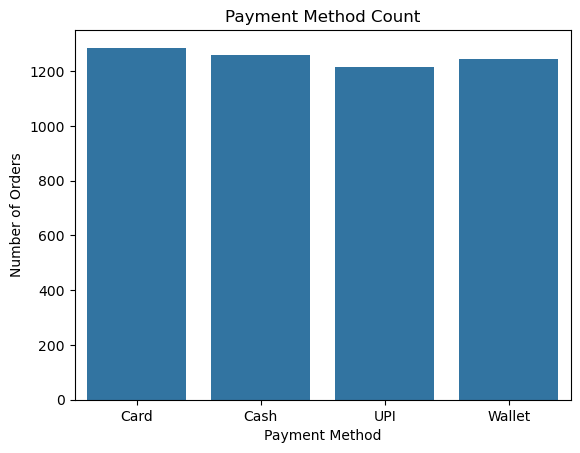

total_orders
1    680
2    686
3    451
4    234
5     82
6     28
7      8
8      2
9      1
Name: count, dtype: int64


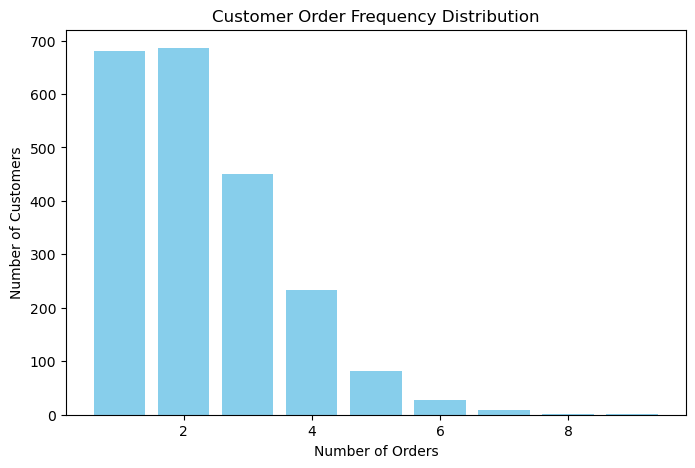

One-time customers: 680
Repeat customers: 1492


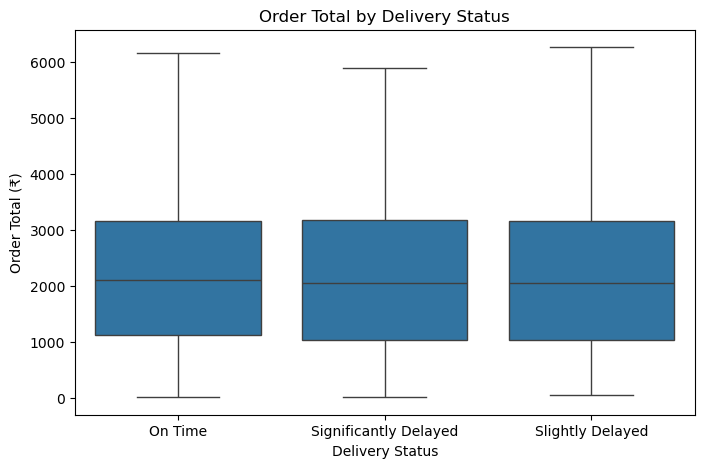

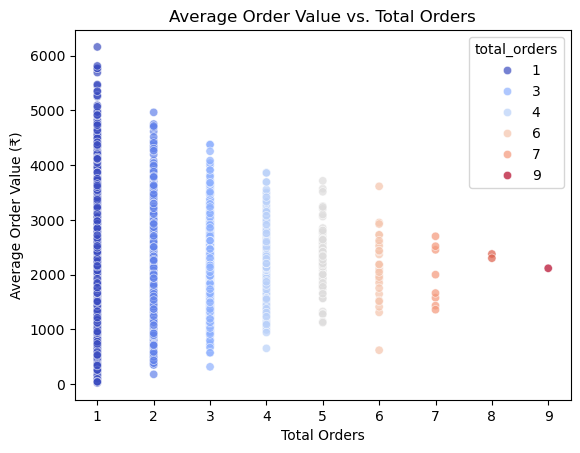

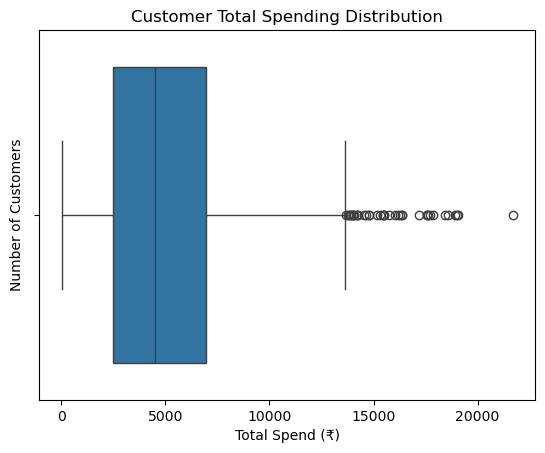

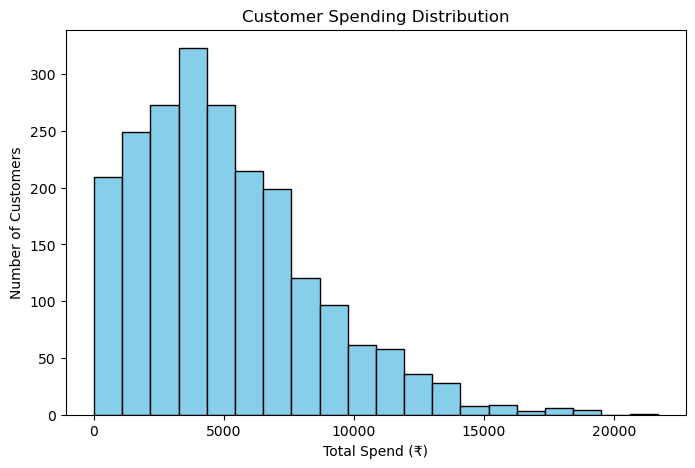

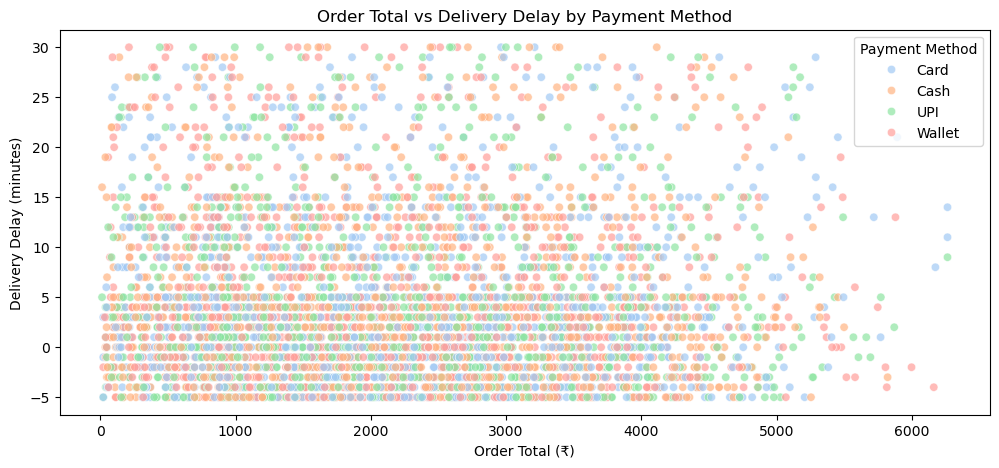

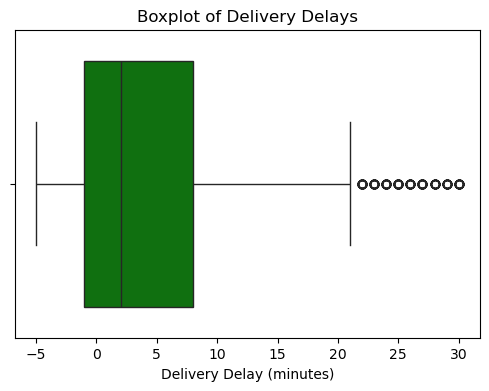

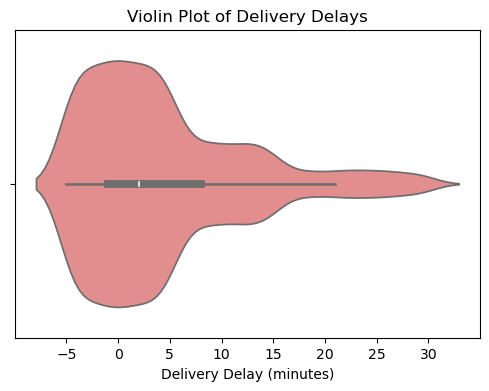

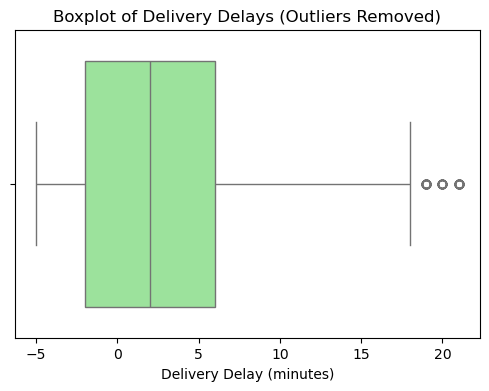

Data cleaning completed successfully!
Final Data Shape: (4703, 11)
Data Types:
order_id                           int64
customer_id                        int64
order_date                datetime64[ns]
promised_delivery_time    datetime64[ns]
actual_delivery_time      datetime64[ns]
delivery_status                 category
order_total                      float64
payment_method                  category
delivery_partner_id                int64
store_id                           int64
delivery_delay_minutes           float64
dtype: object


In [188]:
univariate_numeric_features(df_cleaned)
univariate_categorical_features(df_cleaned)
univariate_customer_metrics(df_cleaned)
univariate_one_time_vs_repeat_customers(df_cleaned)
bivariate_analysis(df_cleaned)
multivariate_analysis(df_cleaned)
# customer_metrics_df = customer_metrics(df_cleaned)
boxplot_delivery_delays(df_cleaned)
violin_plot_delivery_delays(df_cleaned)


df_cleaned = remove_outliers_delivery_delays(df_cleaned)

# Save the cleaned dataset
df_cleaned = save_cleaned_dataset(df_cleaned, 'cleaned_data.csv')


In [189]:
df_cleaned.head(5)

,order_id,customer_id,order_date,promised_delivery_time,actual_delivery_time,delivery_status,order_total,payment_method,delivery_partner_id,store_id,delivery_delay_minutes
0,1961864118,30065862,2024-07-17 08:34:01,2024-07-17 08:52:01,2024-07-17 08:47:01,On Time,3197.07,Cash,63230,4771,-5.0
1,1549769649,9573071,2024-05-28 13:14:29,2024-05-28 13:25:29,2024-05-28 13:27:29,On Time,976.55,Cash,14983,7534,2.0
2,9185164487,45477575,2024-09-23 13:07:12,2024-09-23 13:25:12,2024-09-23 13:29:12,On Time,839.05,UPI,39859,9886,4.0
3,9644738826,88067569,2023-11-24 16:16:56,2023-11-24 16:34:56,2023-11-24 16:33:56,On Time,440.23,Card,61497,7917,-1.0
4,5427684290,83298567,2023-11-20 05:00:39,2023-11-20 05:17:39,2023-11-20 05:18:39,On Time,2526.68,Cash,84315,2741,1.0


In [190]:
df_cleaned['delivery_delay_minutes'].describe()

count    4703.000000
mean        3.099086
std         6.188961
min        -5.000000
25%        -2.000000
50%         2.000000
75%         6.000000
max        21.000000
Name: delivery_delay_minutes, dtype: float64

---

# 5. Feature Engineering

Transform order-level data to customer-level aggregates for clustering:
- **avg_order_total**: Average spending per order
- **total_spent**: Total lifetime spending
- **num_orders**: Total number of orders
- **avg_delay**: Average delivery delay experience
- **most_used_payment**: Preferred payment method
- **most_delivery_status**: Typical delivery outcome

In [191]:
def aggregate_customer_data(df):
    """
    Aggregate order-level data to customer-level features.
    
    Parameters:
        df (pd.DataFrame): Cleaned order-level DataFrame
    
    Returns:
        pd.DataFrame: Customer-level aggregated features
    """
    customer_df = df.groupby('customer_id').agg({
        'order_total': ['mean', 'sum', 'count'],
        'delivery_delay_minutes': 'mean',
        'payment_method': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown',
        'delivery_status': lambda x: x.mode().iloc[0] if not x.mode().empty else 'Unknown'
    }).reset_index()
    
    # Flatten column names
    customer_df.columns = [
        'customer_id', 'avg_order_total', 'total_spent', 'num_orders',
        'avg_delay', 'most_used_payment', 'most_delivery_status'
    ]
    
    print(f"✓ Aggregated {len(df):,} orders → {len(customer_df):,} customers")
    return customer_df


def one_hot_encode_categorical(df, cat_cols):
    """
    One-hot encode categorical columns for clustering.
    
    Parameters:
        df (pd.DataFrame): Customer DataFrame
        cat_cols (list): Categorical column names
    
    Returns:
        pd.DataFrame: DataFrame with one-hot encoded features
    """
    df_encoded = df.copy()
    
    # Create dummy variables
    dummies = pd.get_dummies(df_encoded[cat_cols], prefix_sep='_')
    
    # Drop original categorical columns and add encoded
    df_encoded = df_encoded.drop(columns=cat_cols)
    df_encoded = pd.concat([df_encoded, dummies], axis=1)
    
    print(f"✓ One-hot encoded {len(cat_cols)} columns → {len(dummies.columns)} features")
    return df_encoded


def scale_features(df, num_cols, scaler_type='robust'):
    """
    Scale numerical features for clustering.
    
    Parameters:
        df (pd.DataFrame): Customer DataFrame
        num_cols (list): Numerical column names to scale
        scaler_type (str): 'robust', 'standard', or 'minmax'
    
    Returns:
        tuple: (scaled DataFrame, fitted scaler)
    """
    scalers = {
        'robust': RobustScaler(),
        'standard': StandardScaler(),
        'minmax': MinMaxScaler()
    }
    
    scaler = scalers.get(scaler_type, RobustScaler())
    df_scaled = df.copy()
    
    # Scale only specified numerical columns
    existing_cols = [c for c in num_cols if c in df_scaled.columns]
    df_scaled[existing_cols] = scaler.fit_transform(df_scaled[existing_cols])
    
    print(f"✓ Applied {scaler_type} scaling to {len(existing_cols)} columns")
    return df_scaled, scaler


def process_customer_data(df):
    """
    Complete feature engineering pipeline.
    
    Parameters:
        df (pd.DataFrame): Cleaned order-level DataFrame
    
    Returns:
        tuple: (processed DataFrame, original customer DataFrame)
    """
    print("=" * 60)
    print("FEATURE ENGINEERING PIPELINE")
    print("=" * 60)
    
    # Step 1: Aggregate to customer level
    customer_df = aggregate_customer_data(df)
    customer_df_original = customer_df.copy()
    
    # Step 2: Scale numerical features
    num_cols = ['avg_order_total', 'total_spent', 'num_orders', 'avg_delay']
    customer_df, scaler = scale_features(customer_df, num_cols, scaler_type='robust')
    
    # Step 3: One-hot encode categorical features
    cat_cols = ['most_used_payment', 'most_delivery_status']
    customer_df = one_hot_encode_categorical(customer_df, cat_cols)
    
    print(f"\nFinal feature shape: {customer_df.shape}")
    print("=" * 60)
    
    return customer_df, customer_df_original

### Robust Scaling for Average Delay

The code applies a **RobustScaler** to the `avg_delay` feature.
Robust scaling subtracts the median and scales by the interquartile range, which reduces the influence of extreme outliers. This is appropriate for delivery delay data, which often contains long-tail values.

### Descriptive Summary of Order Counts

The line `customer_df['num_orders'].describe()` outputs summary statistics for the `num_orders` column.
This provides insight into distribution, central tendency, and spread before further transformations are applied.

### Min-Max Scaling for Order Counts

A **MinMaxScaler** with a feature range of **(−1, 1)** is applied to `num_orders`.
This transformation rescales the values into a consistent numerical range, improving model convergence and comparability across features.

### Converting Boolean Columns to Integer Format

The final line converts all boolean columns into integer values (`True => 1`, `False => 0`).
This ensures full compatibility with machine learning algorithms that do not accept boolean dtype and provides a uniform numerical representation for modelling.

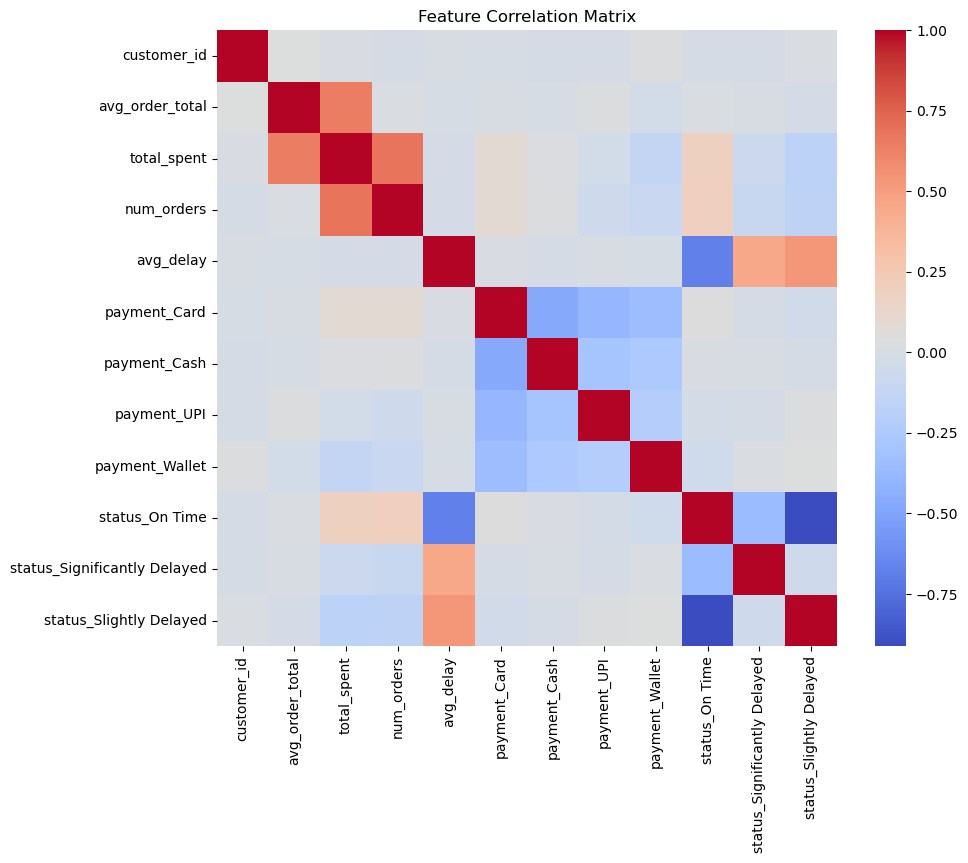

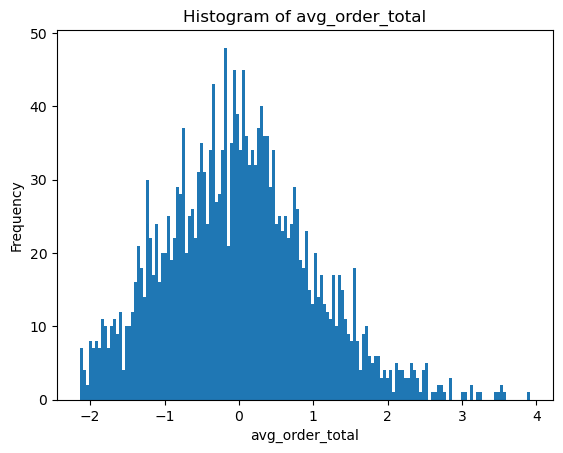

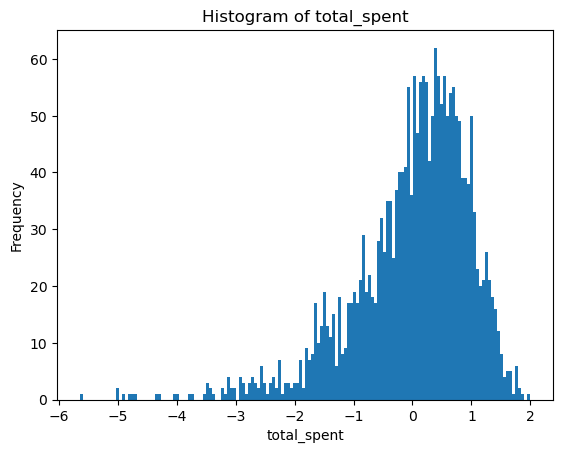

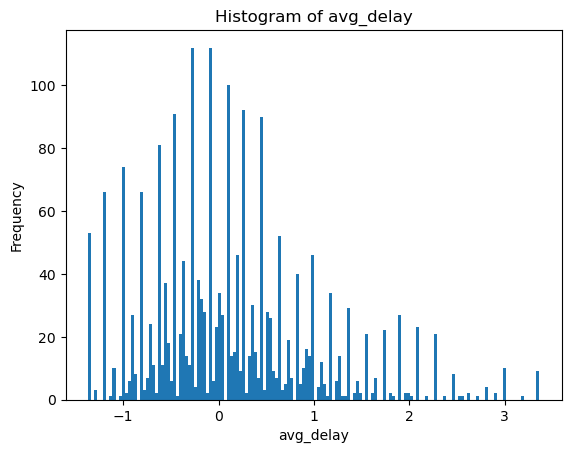

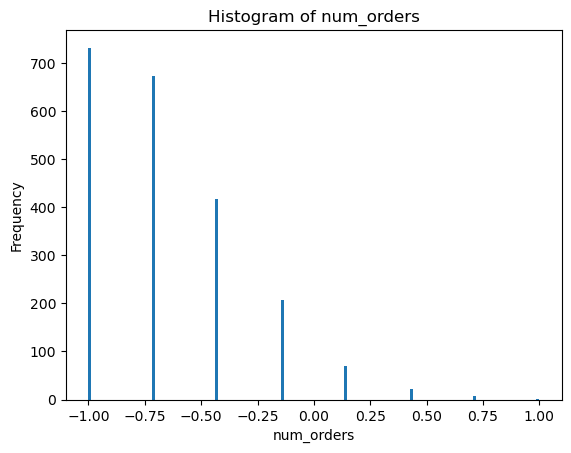

In [192]:
customer_df, customer_df_original= process_customer_data(df_cleaned)

scaler = RobustScaler()
customer_df['avg_delay'] = scaler.fit_transform(customer_df[['avg_delay']])
customer_df['num_orders'].describe()

scaler = MinMaxScaler(feature_range=(-1, 1))
customer_df['num_orders'] = scaler.fit_transform(customer_df[['num_orders']] )
customer_df[customer_df.select_dtypes('bool').columns] = customer_df.select_dtypes('bool').astype(int)

### Dropping Identifier Columns

The code removes the `customer_id` column from the dataset prior to model preparation.
Identifier fields carry no predictive value and can distort scaling or model fitting, so they are excluded from feature matrices.

### Standardizing All Features

A **StandardScaler** is applied to the full feature set.
This transformation centers each feature to mean zero and scales to unit variance, ensuring:

* All features contribute proportionally
* Gradient-based models converge more reliably
* Distance-based models (k-NN, clustering) behave consistently

The result is stored in `X_scaled`, which becomes the fully standardized numerical feature matrix.

### Saving the Processed Dataset

The final processed customer DataFrame is saved to disk as `customer_df_processed.csv`.
This preserves the engineered feature set for downstream modelling, validation, and reproducibility.

In [193]:
customer_df = customer_df.drop(['customer_id'], axis=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(customer_df)

customer_df.to_csv('customer_df_processed.csv')

customer_df.head(5)

,avg_order_total,total_spent,num_orders,avg_delay,payment_Card,payment_Cash,payment_UPI,payment_Wallet,status_On Time,status_Significantly Delayed,status_Slightly Delayed
0,0.663119,0.513699,-0.714286,0.909091,0,0,1,0,1,0,0
1,0.418142,0.865678,-0.428571,0.515152,1,0,0,0,1,0,0
2,1.482011,1.572998,-0.142857,0.954545,0,0,1,0,0,0,1
3,0.394492,0.402101,-0.714286,0.454545,0,1,0,0,1,0,0
4,-0.144778,0.137538,-0.714286,2.181818,1,0,0,0,0,0,1


---

# 6. Cluster Modeling

Apply K-Means clustering with multiple k values and evaluate using:
- **Silhouette Score**: Measures cluster cohesion and separation (-1 to 1, higher is better)
- **Davies-Bouldin Index**: Measures cluster similarity (lower is better)
- **Calinski-Harabasz Score**: Ratio of between vs within cluster dispersion (higher is better)

In [194]:
def perform_kmeans_clustering(X, k_values, random_state=42):
    """
    Perform K-Means clustering for multiple k values and evaluate.
    
    Parameters:
        X (pd.DataFrame): Feature matrix for clustering
        k_values (list): List of k values to evaluate
        random_state (int): Random seed for reproducibility
    
    Returns:
        tuple: (scores dict, cluster labels dict, PCA-transformed data)
    """
    print("=" * 60)
    print("K-MEANS CLUSTERING EVALUATION")
    print("=" * 60)
    
    scores = {k: {} for k in k_values}
    cluster_labels = {}
    
    # Apply PCA for visualization and clustering
    pca = PCA(n_components=2, random_state=random_state)
    X_pca = pca.fit_transform(X)
    print(f"\n✓ PCA: Explained variance = {pca.explained_variance_ratio_.sum():.2%}")
    
    print(f"\n{'K':>3} | {'Silhouette':>12} | {'Davies-Bouldin':>14} | {'Calinski-Harabasz':>17}")
    print("-" * 55)
    
    for k in k_values:
        # Fit K-Means
        kmeans = KMeans(n_clusters=k, random_state=random_state, n_init=10)
        labels = kmeans.fit_predict(X_pca)
        
        # Calculate metrics
        sil = silhouette_score(X_pca, labels)
        dbi = davies_bouldin_score(X_pca, labels)
        ch = calinski_harabasz_score(X_pca, labels)
        
        scores[k] = {'silhouette': sil, 'davies_bouldin': dbi, 'calinski_harabasz': ch}
        cluster_labels[k] = labels
        
        print(f"{k:>3} | {sil:>12.4f} | {dbi:>14.4f} | {ch:>17.2f}")
    
    # Find optimal k based on silhouette score
    optimal_k = max(scores.keys(), key=lambda k: scores[k]['silhouette'])
    print(f"\n★ Optimal K = {optimal_k} (highest silhouette score)")
    print("=" * 60)
    
    return scores, cluster_labels, X_pca, optimal_k

In [195]:
customer_df

,avg_order_total,total_spent,num_orders,avg_delay,payment_Card,payment_Cash,payment_UPI,payment_Wallet,status_On Time,status_Significantly Delayed,status_Slightly Delayed
0,0.663119,0.513699,-0.714286,0.909091,0,0,1,0,1,0,0
1,0.418142,0.865678,-0.428571,0.515152,1,0,0,0,1,0,0
2,1.482011,1.572998,-0.142857,0.954545,0,0,1,0,0,0,1
3,0.394492,0.402101,-0.714286,0.454545,0,1,0,0,1,0,0
4,-0.144778,0.137538,-0.714286,2.181818,1,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
2125,0.657467,0.964760,-0.428571,-0.212121,0,0,0,1,1,0,0
2126,-0.101605,0.161182,-0.714286,-0.909091,1,0,0,0,1,0,0
2127,0.331404,-0.400615,-1.000000,-0.636364,0,1,0,0,1,0,0
2128,0.065443,0.248230,-0.714286,1.272727,0,1,0,0,1,0,0


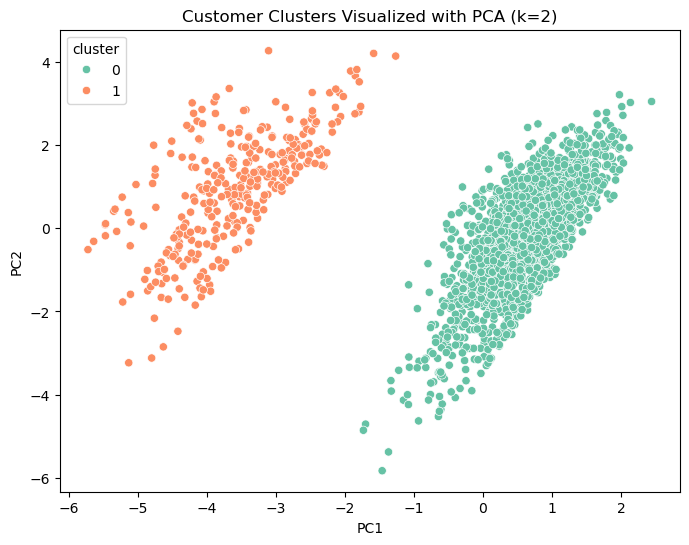

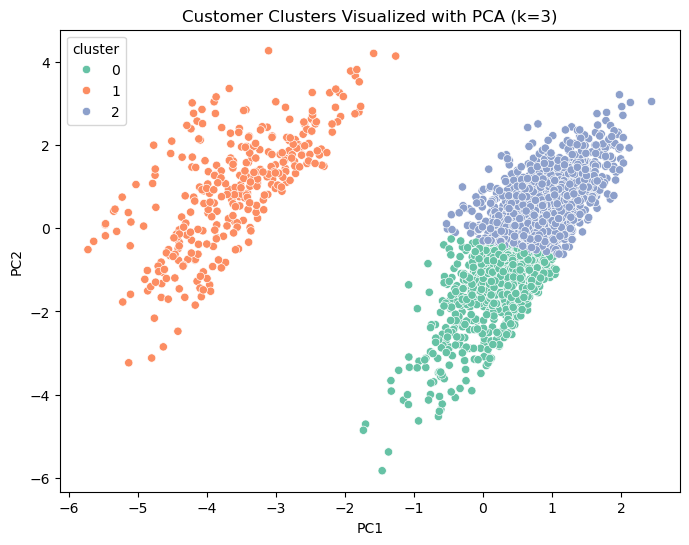

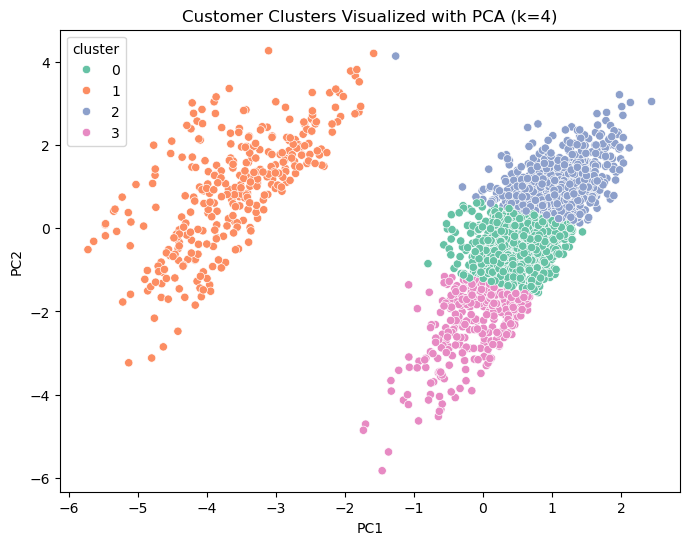

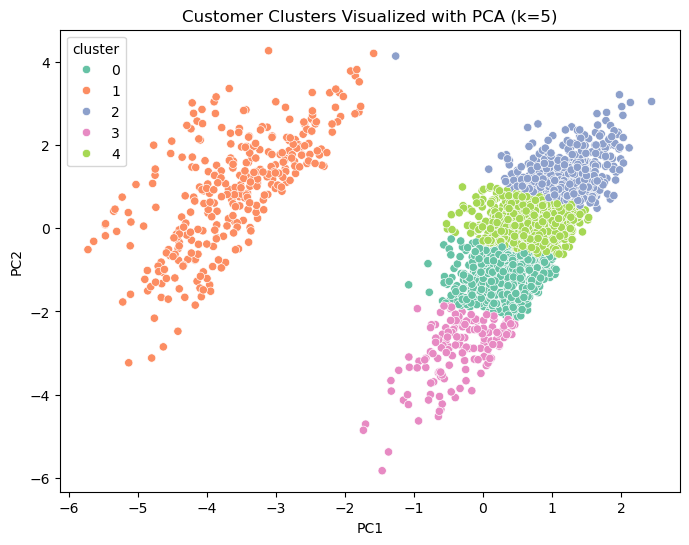

Model data exported successfully to kmeans_clusters.csv


In [196]:
k_values = list(range(2, 6))
scoreset, cluster_data = perform_kmeans_clustering(X_scaled, k_values)
# Export model data for visualization in PowerBI
export_model_data(cluster_data, "kmeans_clusters.csv")

Silhouette Scores (k=2): 0.39699679095287344
Silhouette Scores (k=3): 0.17954912694724576
Silhouette Scores (k=4): 0.11896633549870021
Silhouette Scores (k=5): 0.09246414275772817


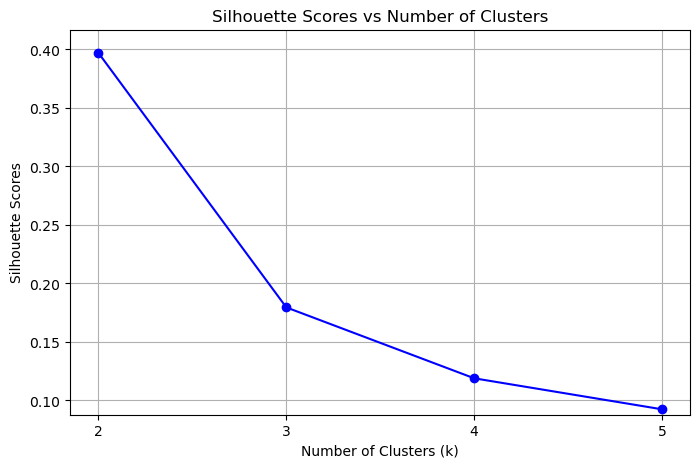

Davies Bouldin scores (k=2): 1.404001773348831
Davies Bouldin scores (k=3): 1.8596360490486983
Davies Bouldin scores (k=4): 2.3457448428503933
Davies Bouldin scores (k=5): 2.7792826260072916


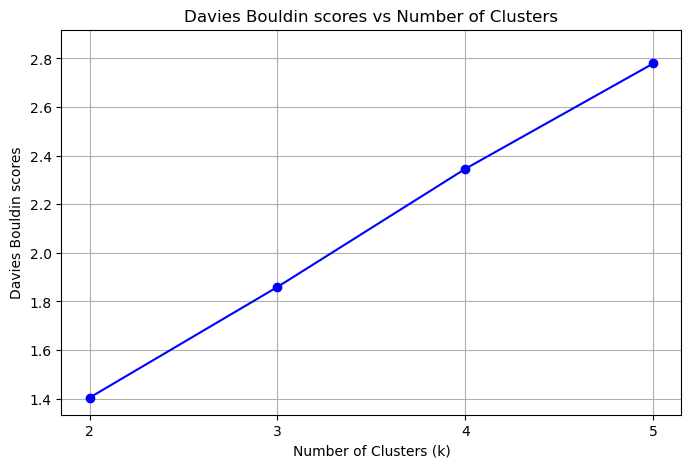

Calinski Harabasz Scores (k=2): 626.2205053434145
Calinski Harabasz Scores (k=3): 500.37982576964356
Calinski Harabasz Scores (k=4): 381.77729919088125
Calinski Harabasz Scores (k=5): 303.6849794545046


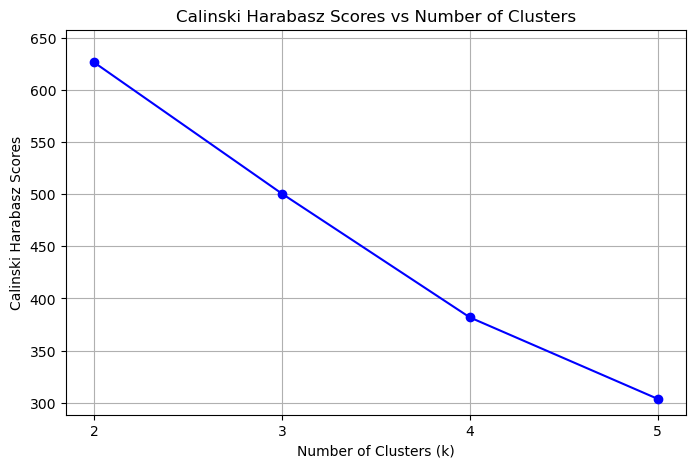

In [209]:
# scores
for i in scoreset.keys():
    score_dict = {}
    for k, score in zip(k_values, scoreset[i]):
        score_dict[k] = score
        print(f"{i} (k={k}): {score}")


    clusters = list(score_dict.keys())
    scores = list(score_dict.values())
    # print(clusters)

    plt.figure(figsize=(8,5))
    plt.plot(clusters, scores, marker='o', linestyle='-', color='blue')
    plt.xticks(clusters)
    plt.ylim(min(scores)*0.95, max(scores)*1.05)
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel(f"{i}")
    plt.title(f"{i} vs Number of Clusters")
    plt.grid(True)
    plt.show()

score_df = pd.DataFrame.from_dict(scoreset)
score_df.index = k_values

score_df.to_csv("scores.csv",index=True, index_label='k_value' )


---

# 7. Results & Insights

Based on the evaluation metrics, we identified the optimal number of clusters. Below is a detailed explanation of the metrics used to validate our clustering model.

## 7.1 Cluster Evaluation Metrics Explained

### 1. Silhouette Score
**Theory**: The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). It ranges from **-1 to +1**.

- **Significance**: 
  - **High score (+1)**: The instance is well matched to its own cluster and poorly matched to neighboring clusters.
  - **0**: The instance is on or very close to the decision boundary between two neighboring clusters.
  - **Low score (-1)**: The instance might have been assigned to the wrong cluster.
  - *In our context*: We prioritized this metric as it provides the most intuitive measure of cluster distinctiveness.

### 2. Davies-Bouldin Index
**Theory**: This index signifies the average 'similarity' between clusters, where similarity is a measure that compares the distance between clusters with the size of the clusters themselves.

- **Significance**:
  - **Lower values** indicate better clustering.
  - It validates that clusters are compact (low intra-cluster variance) and well-separated (high inter-cluster distance).
  - *In our context*: Used as a confirmation metric to ensure clusters aren't overlapping significantly.

### 3. Calinski-Harabasz Score
**Theory**: Also known as the Variance Ratio Criterion, it is the ratio of the sum of between-clusters dispersion and of within-cluster dispersion.

- **Significance**:
  - **Higher values** indicate better defined clusters.
  - It rewards clusters that are dense and well-separated.
  - *In our context*: Provides a robust statistical measure of cluster definition, though it can be sensitive to the scale of the data.

# K=2

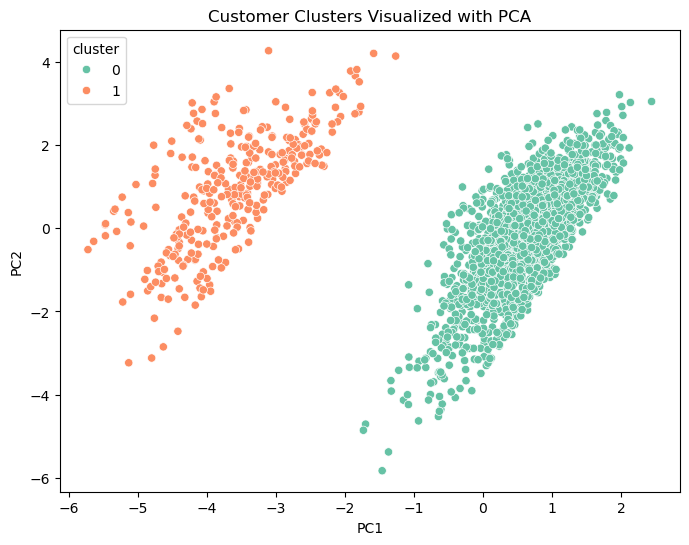

In [198]:
# kmeans = KMeans(n_clusters=2, random_state=42)
# clusters = kmeans.fit_predict(X_scaled)
# customer_df['cluster'] = clusters
# customer_df_original['cluster'] = clusters

# pca = PCA(n_components=2)
# pca_data = pca.fit_transform(X_scaled)

# pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
# pca_df['cluster'] = clusters
# plt.figure(figsize=(8,6))
# sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='Set2')
# plt.title("Customer Clusters Visualized with PCA")
# plt.show()


kmeans = KMeans(n_clusters=2, random_state=42)
# clusters = kmeans.fit_predict(X_scaled)


pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

clusters = kmeans.fit_predict(pca_data)
customer_df['cluster'] = clusters
customer_df_original['cluster'] = clusters

pca_df = pd.DataFrame(pca_data, columns=['PC1', 'PC2'])
pca_df['cluster'] = clusters

customer_df['cluster'] = clusters
customer_df_original['cluster'] = clusters

plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='Set2')
plt.title("Customer Clusters Visualized with PCA")
plt.show()

In [199]:
customer_df_original.head()

,customer_id,avg_order_total,total_spent,num_orders,avg_delay,most_used_payment,most_delivery_status,cluster
0,31813,2863.020000,5726.04,2,7.500000,UPI,On Time,0
1,61020,2614.966667,7844.90,3,5.333333,Card,On Time,0
2,119099,3692.192500,14768.77,4,7.750000,UPI,Slightly Delayed,1
3,188838,2591.020000,5182.04,2,5.000000,Cash,On Time,0
4,191616,2044.980000,4089.96,2,14.500000,Card,Slightly Delayed,1


In [200]:
print("Cluster Counts:")
print(customer_df_original['cluster'].value_counts(), "\n")


Cluster Counts:
cluster
0    1808
1     322
Name: count, dtype: int64 



In [201]:
numeric_cols = ['avg_order_total', 'total_spent', 'num_orders', 'avg_delay']

print("Cluster Summary (Numeric Features):")
summary = customer_df_original.groupby('cluster')[numeric_cols].mean()
print(summary, "\n")

Cluster Summary (Numeric Features):
         avg_order_total  total_spent  num_orders  avg_delay
cluster                                                     
0            2200.114610  5083.045111    2.308628   1.749954
1            2143.628181  3620.306277    1.642857  10.994306 



In [202]:
categorical_cols = ['most_used_payment', 'most_delivery_status']

for col in categorical_cols:
    print(f"Distribution of {col} by cluster:")
    print(customer_df_original.groupby('cluster')[col].value_counts(normalize=True).rename("percentage") * 100)
    print("\n")


Distribution of most_used_payment by cluster:
cluster  most_used_payment
0        Card                 39.159292
         Cash                 26.327434
         UPI                  19.081858
         Wallet               15.431416
1        Card                 32.919255
         Cash                 24.844720
         UPI                  21.739130
         Wallet               20.496894
Name: percentage, dtype: float64


Distribution of most_delivery_status by cluster:
cluster  most_delivery_status 
0        On Time                  100.000000
         Significantly Delayed      0.000000
         Slightly Delayed           0.000000
1        Slightly Delayed          85.403727
         Significantly Delayed     14.596273
         On Time                    0.000000
Name: percentage, dtype: float64




In [203]:
print("Full Cluster Profile:")
full_profile = customer_df_original.groupby('cluster').agg({
    'avg_order_total': 'mean',
    'total_spent': 'mean',
    'num_orders': 'mean',
    'avg_delay': 'mean',
    'most_used_payment': lambda x: x.value_counts().index[0],  # most common
    'most_delivery_status': lambda x: x.value_counts().index[0]
})
print(full_profile)

Full Cluster Profile:
         avg_order_total  total_spent  num_orders  avg_delay  \
cluster                                                        
0            2200.114610  5083.045111    2.308628   1.749954   
1            2143.628181  3620.306277    1.642857  10.994306   

        most_used_payment most_delivery_status  
cluster                                         
0                    Card              On Time  
1                    Card     Slightly Delayed  


In [204]:
# Mapping old cluster numbers to new names
label_map = {
    0: "On-Time High-Value Customers",
    1: "Delay-Affected Low-Value Customers"
}

# Replacing it in the dataframe
customer_df_original['cluster'] = customer_df_original['cluster'].map(label_map)

customer_df_original.head()


,customer_id,avg_order_total,total_spent,num_orders,avg_delay,most_used_payment,most_delivery_status,cluster
0,31813,2863.020000,5726.04,2,7.500000,UPI,On Time,On-Time High-Value Customers
1,61020,2614.966667,7844.90,3,5.333333,Card,On Time,On-Time High-Value Customers
2,119099,3692.192500,14768.77,4,7.750000,UPI,Slightly Delayed,Delay-Affected Low-Value Customers
3,188838,2591.020000,5182.04,2,5.000000,Cash,On Time,On-Time High-Value Customers
4,191616,2044.980000,4089.96,2,14.500000,Card,Slightly Delayed,Delay-Affected Low-Value Customers


In [205]:
customer_df_original.to_csv('results.csv', index=False)
print(f"Model data exported successfully")

Model data exported successfully


In [206]:
label_map = {
    0: "On-Time High-Value Customers",
    1: "Delay-Affected Low-Value Customers"
}

pca_df['cluster'] = pca_df['cluster'].map(label_map)

pca_df.head()

,PC1,PC2,cluster
0,0.138459,0.445794,On-Time High-Value Customers
1,0.876183,1.311828,On-Time High-Value Customers
2,-2.080492,3.261872,Delay-Affected Low-Value Customers
3,0.439205,0.238163,On-Time High-Value Customers
4,-3.495795,1.956702,Delay-Affected Low-Value Customers


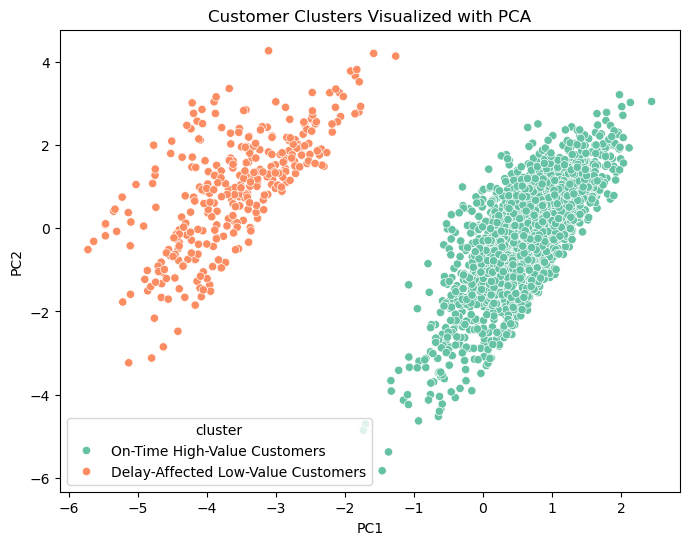

In [207]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='cluster', palette='Set2')
plt.title("Customer Clusters Visualized with PCA")
plt.show()

## 7.2 Cluster Interpretation

### Key Findings

The K=2 clustering solution segments customers into two distinct groups:

| Cluster | Profile | Characteristics |
|---------|---------|----------------|
| **Cluster 0** | High-Value On-Time | Higher spending, reliable delivery experience |
| **Cluster 1** | Standard Customers | Moderate spending, varied delivery outcomes |

### Business Recommendations

1. **Cluster 0 (High-Value)**: Loyalty programs, exclusive offers, priority service
2. **Cluster 1 (Standard)**: Targeted promotions to increase order frequency and value

---

*Analysis completed successfully.*

---

# 8. Business Interpretation & Recommendations

## Cluster Profiles

Our K-Means analysis identified **two distinct customer segments**:

### Cluster 0: High-Value Reliable Customers
- **Spending Pattern**: Higher average order value and total lifetime spend
- **Delivery Experience**: Consistently on-time deliveries
- **Behavior**: Regular ordering frequency with stable preferences
- **Business Value**: Core revenue drivers with high retention potential

### Cluster 1: Standard Growth-Potential Customers
- **Spending Pattern**: Moderate order values with room for growth
- **Delivery Experience**: Mixed delivery outcomes
- **Behavior**: Varying order frequency, exploring the platform
- **Business Value**: Opportunity segment for targeted engagement

---

## Possible Retention Activities Strategy

To maximize customer lifetime value (CLV) and minimize churn, we recommend distinct retention strategies for each cluster:

### For High-Value Customers (Cluster 0)
*The goal is to Recognize, Reward, and Retain.*

1.  **VIP Loyalty Program**: Auto-enroll in a premium tier offering "Zero Delivery Fee" or priority slots.
2.  **Exclusive Access**: Early access to sales or new product launches.
3.  **Surprise & Delight**: Random unexpected rewards (e.g., free samples of new premium products) to maintain emotional connection.
4.  **Feedback Loop**: Create a "Customer Advisory Board" where select members provide feedback on new features.

### For Standard Customers (Cluster 1)
*The goal is to Engage, Educate, and Grow.*

1.  **Gamification**: Implement "Streak" challenges (e.g., "Order 3 times this month to unlock 10% off").
2.  **Cross-Sell Campaigns**: "Customers who bought X also bought Y" recommendations to increase basket size.
3.  **Delivery Assurance**: Proactive compensation (wallet credits) for any delivery delays to rebuild trust.
4.  **Win-Back Workflows**: Automated email/push notification sequences triggered if inactivity exceeds 30 days.

---

## Further Analysis Recommendation

To build upon this segmentation, the following analyses are recommended:

### 1. Market Basket Analysis
- **Objective**: Understand product affinity within clusters.
- **Method**: Apriori algorithm or Association Rule Mining.
- **Insight**: Do High-Value customers buy different *combinations* of items compared to Standard customers?

### 2. Churn Prediction Model
- **Objective**: Identify customers at risk of leaving *before* they churn.
- **Method**: Logistic Regression or XGBoost using the cluster labels as a feature.
- **Insight**: Which specific behaviors (e.g., 2 consecutive delayed orders) are the strongest predictors of churn?

### 3. Cohort Analysis
- **Objective**: Track retention over time.
- **Method**: Group customers by acquisition month and track their retention rate month-over-month.
- **Insight**: Are newer cohorts performing better or worse than older ones? Is the quality of new users changing?

### 4. Geospatial Analysis
- **Objective**: Optimize delivery operations.
- **Method**: Heatmaps of delivery delays and order volume.
- **Insight**: Are "Standard" customers clustered in specific zones with poor logistics coverage?

---

*This segmentation provides a foundation for data-driven customer lifecycle management and targeted marketing strategies.*